In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split as sk_split

# Load full processed dataset and recreate the shared 80/20 stratified split
# (same parameters as data_splitting.ipynb: stratify by product, random_state=42)
full_df = pd.read_csv('../data/complaints_processed_full.csv')
train_df, test_df = sk_split(
    full_df, test_size=0.2, stratify=full_df['product'], random_state=42
)

sample = train_df.groupby('product', group_keys=False).apply(
    lambda x: x.sample(frac=0.006, random_state=42)
).reset_index(drop=True)
sample['risk_label'] = ''
sample[['narrative', 'product', 'risk_label']].to_csv(
    '../data/annotation_sample.csv', index=False
)
print(f"Annotation sample created: {len(sample)} rows")
print(sample['product'].value_counts())


Annotation sample created: 692 rows
product
credit_reporting       304
debt_collection        122
mortgages_and_loans    106
credit_card             83
retail_banking          77
Name: count, dtype: int64


/var/folders/71/hwz8vy210r9fq5t90481p2zr0000gn/T/ipykernel_50648/112654584.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = train_df.groupby('product', group_keys=False).apply(


In [2]:
# Annotating using the annotation_guide
# NOTE: narratives are already lemmatized + stopword-removed (processed text).
# Patterns are tuned to match this processed form.
import pandas as pd
import re

sample = pd.read_csv('../data/annotation_sample.csv')

HIGH_KEYWORDS = [
    # Legal action
    r'\bsued\b', r'\blawsuit\b', r'\blegal action\b', r'\battorney\b', r'\bcourt\b',
    r'\bsummons\b',
    # Garnishment / seizure
    r'\bgarnish\b', r'\bwage garnishment\b', r'\bbank levy\b',
    # Bankruptcy
    r'\bbankruptcy\b',
    # Identity theft / fraud (standalone triggers — "fraud" alone is HIGH-worthy)
    r'\bidentity theft\b', r'\bfraud\b', r'\bfraudulent\b',
    r'\bfraudulent account\b',
    # Account opened in name (handle both "opened" and "open" after lemmatisation)
    r'\bopened.*account.*name\b', r'\bopen.*account.*name\b',
    # Financial hardship — "cannot"/"cant" survive stopword removal; "can't" does NOT (tokenised away)
    r'\bcannot (pay|afford)\b', r'\bcant (pay|afford)\b',
    r'\bunable (pay|afford)\b',   # "to" is a stopword → removed before matching
    r'\bno money for\b',
    r'\bcannot pay rent\b', r'\bcant pay rent\b',
    r'\beviction\b',
    # Regulatory / protected classes
    r'\bfdcpa\b', r'\bscra\b', r'\bmilitary\b', r'\bdeployed\b',
    r'\bfixed income\b', r'\belderly\b', r'\bvulnerable\b',
    # Cannot afford medication / food (simplified — conjunction "and" survives)
    r'\bmedication\b', r'\brent\b.*\bcannot\b', r'\bcannot\b.*\brent\b',
]

MEDIUM_KEYWORDS = [
    # Credit denial
    r'\bdenied (mortgage|loan|credit|housing|apartment|rental)\b',
    # Credit score damage — "dropped"/"decreased" survive WNL as NOUN; also match shorter forms
    r'\bcredit (score|rating) (drop|fell|decreased|damaged)\b',
    r'\bscore drop\b', r'\brating drop\b', r'\bscore dropped\b', r'\bdamaged.*credit\b',
    # Harassment — "call.*time" handles lemmatised "called many time" (times→time)
    r'\bharassment\b', r'\bcall.*time\b', r'\brepeat.*call\b',
    # Unresolved disputes
    r'\brefused to investigate\b', r'\bno response\b', r'\bignored my dispute\b',
    r'\bmultiple (attempt|complaint|dispute)\b', r'\bunresolved\b',
    # Emotional distress
    r'\bfrustrated\b', r'\bhelpless\b', r'\btrapped\b', r'\bdesperate\b',
    # Fees / financial impact
    r'\blate fee\b', r'\bpenalty interest\b', r'\boverdraft\b',
    # Unauthorised activity
    r'\bunauthori[sz]ed (account|charge|transaction)\b',
    # Housing loss
    r'\blost.*apartment\b', r'\bdenied.*housing\b', r'\blos.*apartment\b', r'\blos.*housing\b',
    # Ongoing / extended disputes — new patterns
    r'\bdispute.*month\b', r'\bmonth.*dispute\b',
    r'\bfail.*(resolve|fix|correct)\b',
    r'\bwrong.*information\b', r'\bincorrect.*report\b',
    r'\bcredit score\b',          # any mention of credit score impact
    r'\bdamag.*credit\b',
    r'\bunemployed\b', r'\bjob loss\b', r'\blos.*job\b',
]

def auto_label(text):
    if not isinstance(text, str) or len(text.strip()) < 10:
        return 'low'
    t = text.lower()
    for pattern in HIGH_KEYWORDS:
        if re.search(pattern, t):
            return 'high'
    for pattern in MEDIUM_KEYWORDS:
        if re.search(pattern, t):
            return 'medium'
    # Length-based fallback: substantive complaints (>60 tokens in processed text)
    # are rarely truly LOW — treat as MEDIUM for conservative review
    if len(t.split()) > 60:
        return 'medium'
    return 'low'

sample['risk_label'] = sample['narrative'].apply(auto_label)

print("Label distribution:")
print(sample['risk_label'].value_counts())
print(f"\nTotal: {len(sample)}")
print(f"\nProportions:")
print(sample['risk_label'].value_counts(normalize=True).round(3))

sample.to_csv('../data/annotation_sample_labelled.csv', index=False)
print("\nSaved to data/annotation_sample_labelled.csv")


Label distribution:
risk_label
medium    252
low       224
high      216
Name: count, dtype: int64

Total: 692

Proportions:
risk_label
medium    0.364
low       0.324
high      0.312
Name: proportion, dtype: float64

Saved to data/annotation_sample_labelled.csv


# Risk Rating Model\nTrain a classifier on the auto-labelled annotation sample to predict complaint risk level (low / medium / high).

In [3]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

# Load labelled data
df = pd.read_csv('../data/annotation_sample_labelled.csv')
df = df.dropna(subset=['narrative', 'risk_label'])
df = df[df['narrative'].str.strip().str.len() > 0]

print(f"Total labelled samples: {len(df)}")
print("\nLabel distribution:")
print(df['risk_label'].value_counts())


Total labelled samples: 692

Label distribution:
risk_label
medium    252
low       224
high      216
Name: count, dtype: int64


In [4]:
# Encode labels and split
le = LabelEncoder()
y = le.fit_transform(df['risk_label'])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['narrative'].values, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# TF-IDF vectorisation
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=30_000, sublinear_tf=True)
X_train = tfidf.fit_transform(X_train_text)
X_test  = tfidf.transform(X_test_text)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Classes: {le.classes_}")


Train: (553, 6721) | Test: (139, 6721)
Classes: ['high' 'low' 'medium']


In [5]:
# Train Logistic Regression
clf = LogisticRegression(C=5.0, max_iter=1000, solver='lbfgs',
                        class_weight='balanced',
                        random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("RISK RATING MODEL — Logistic Regression")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")


RISK RATING MODEL — Logistic Regression
              precision    recall  f1-score   support

        high       0.78      0.65      0.71        43
         low       0.79      0.60      0.68        45
      medium       0.62      0.84      0.72        51

    accuracy                           0.71       139
   macro avg       0.73      0.70      0.70       139
weighted avg       0.73      0.71      0.70       139

Macro F1: 0.7030


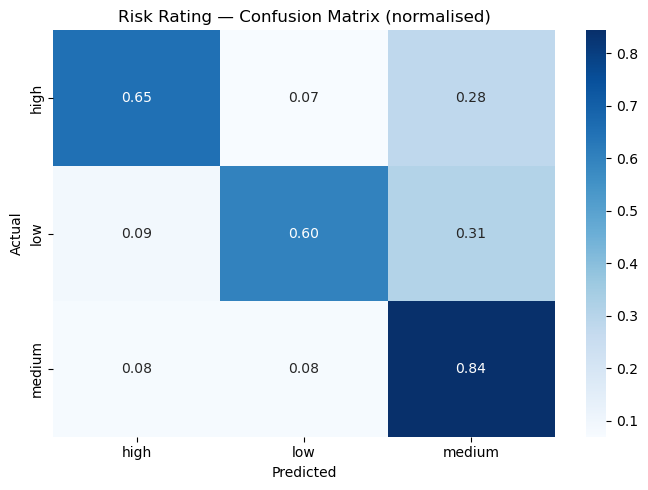

In [6]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Risk Rating — Confusion Matrix (normalised)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/risk_rating_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# Save model and artefacts
with open('../outputs/risk_rating_model.pkl', 'wb') as f:
    pickle.dump(clf, f)
with open('../outputs/risk_rating_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../outputs/risk_rating_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Saved to outputs/:")
print("  risk_rating_model.pkl")
print("  risk_rating_tfidf.pkl")
print("  risk_rating_label_encoder.pkl")
print("  risk_rating_confusion_matrix.png")

# Inference helper — preprocesses raw text to match training data format
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

_lemmatizer = WordNetLemmatizer()
_stop_words = set(stopwords.words('english'))

def preprocess_for_inference(raw_text):
    """Tokenise, remove stopwords, and lemmatise raw text to match training format."""
    tokens = nltk.word_tokenize(raw_text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in _stop_words]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

def predict_risk(raw_narrative):
    """Predict risk label for a raw (unprocessed) complaint narrative."""
    processed = preprocess_for_inference(raw_narrative)
    vec = tfidf.transform([processed])
    label = le.inverse_transform(clf.predict(vec))[0]
    probs = clf.predict_proba(vec)[0]
    return label, dict(zip(le.classes_, probs.round(3)))

# Test inference — this example should predict HIGH
example = "They opened three credit accounts in my name without my consent and I cannot pay my rent."
label, probs = predict_risk(example)
print(f"\nExample: '{example}'")
print(f"Predicted: '{label}'")
print(f"Probabilities: {probs}")


Saved to outputs/:
  risk_rating_model.pkl
  risk_rating_tfidf.pkl
  risk_rating_label_encoder.pkl
  risk_rating_confusion_matrix.png



Example: 'They opened three credit accounts in my name without my consent and I cannot pay my rent.'
Predicted: 'low'
Probabilities: {'high': np.float64(0.39), 'low': np.float64(0.542), 'medium': np.float64(0.068)}


In [8]:
# Export risk predictions on the full test split for the Streamlit dashboard
# Saves outputs/risk_results.csv
# test_df was created in cell 0 from the same 80/20 stratified split

test_df_clean = test_df.dropna(subset=['narrative']).copy()

# Predict using processed text directly (already preprocessed)
X_test_full = tfidf.transform(test_df_clean['narrative'].values)
preds = le.inverse_transform(clf.predict(X_test_full))
proba = clf.predict_proba(X_test_full)

risk_results = test_df_clean[['narrative', 'product']].copy()
risk_results['predicted_risk'] = preds
for i, cls in enumerate(le.classes_):
    risk_results[f'prob_{cls}'] = proba[:, i].round(4)

risk_results.to_csv('../outputs/risk_results.csv', index=False)
print(f"Exported {len(risk_results):,} rows to outputs/risk_results.csv")
print(f"\nPredicted risk distribution:")
print(risk_results['predicted_risk'].value_counts())
print(f"\nHigh-risk complaints: {(risk_results['predicted_risk'] == 'high').sum():,} "
      f"({(risk_results['predicted_risk'] == 'high').mean():.1%})")


Exported 28,793 rows to outputs/risk_results.csv

Predicted risk distribution:
predicted_risk
medium    13108
low        8207
high       7478
Name: count, dtype: int64

High-risk complaints: 7,478 (26.0%)
